In [2]:
import os
import sys
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import DataLoader

scripts_path = os.path.join(os.getcwd(), 'scripts')
if scripts_path not in sys.path:
    sys.path.insert(0, scripts_path)

from train import MusicLSTM, MusicDataset

base_dir = os.getcwd()
data_path = os.path.join(base_dir, 'data', 'dataframes', 'final_features.pkl')
model_path = os.path.join(base_dir, 'models', 'music_lstm.pth')

print(f"Loading data from: {data_path}")
df = pd.read_pickle(data_path)
dataset = MusicDataset(df, seq_length=50)

subset_indices = np.random.choice(len(dataset), size=2000, replace=False)
eda_subset = torch.utils.data.Subset(dataset, subset_indices)
dataloader = DataLoader(eda_subset, batch_size=64, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MusicLSTM(input_dim=17, hidden_dim=128, num_layers=3, vocab_size=36)

print(f"Loading model weights from: {model_path}")
model.load_state_dict(torch.load(model_path, map_location=device))
model.to(device)
model.eval()
print("Model loaded successfully and set to evaluation mode.")

Loading data from: d:\Tehran_University\6th_semester\Data Science\UT-DataScience-Spring2026\Assignments\Final_Project\data\dataframes\final_features.pkl
[Dataset] Building sequences with seq_length=50 ...
[Dataset] Finished. Total sequences: 4353803
Loading model weights from: d:\Tehran_University\6th_semester\Data Science\UT-DataScience-Spring2026\Assignments\Final_Project\models\music_lstm.pth
Model loaded successfully and set to evaluation mode.


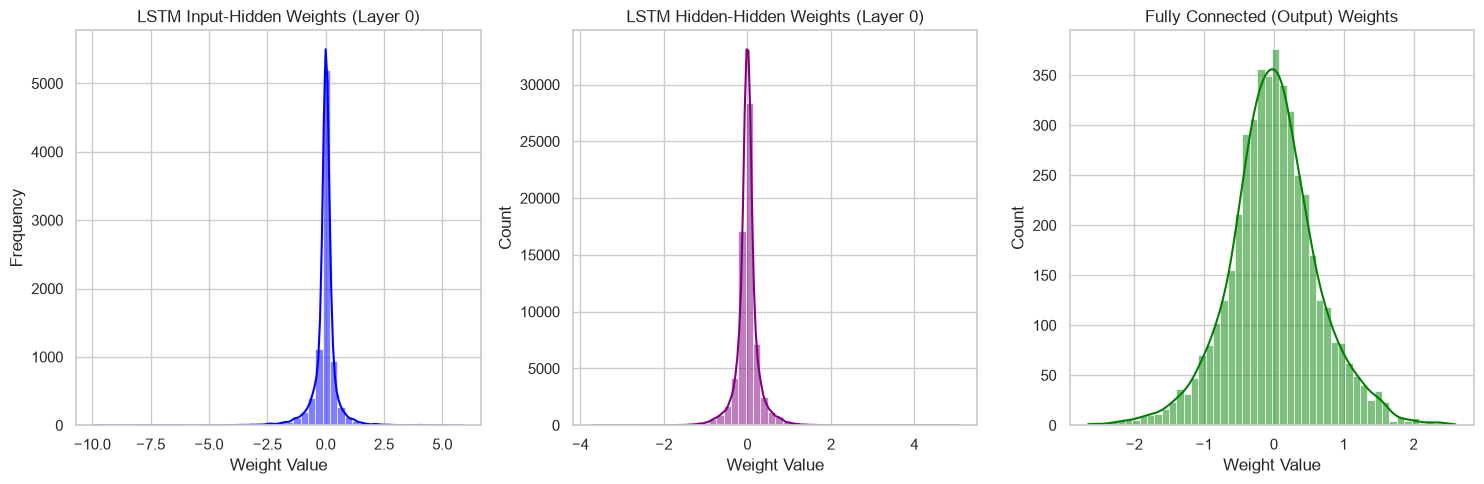

FC Layer Weight Mean: -0.003983, Std: 0.638886


In [3]:
plt.figure(figsize=(15, 5))
sns.set_theme(style="whitegrid")

plt.subplot(1, 3, 1)
lstm_weights = model.lstm.weight_ih_l0.detach().cpu().numpy().flatten()
sns.histplot(lstm_weights, bins=50, color='blue', kde=True)
plt.title("LSTM Input-Hidden Weights (Layer 0)")
plt.xlabel("Weight Value")
plt.ylabel("Frequency")

plt.subplot(1, 3, 2)
lstm_hh_weights = model.lstm.weight_hh_l0.detach().cpu().numpy().flatten()
sns.histplot(lstm_hh_weights, bins=50, color='purple', kde=True)
plt.title("LSTM Hidden-Hidden Weights (Layer 0)")
plt.xlabel("Weight Value")

plt.subplot(1, 3, 3)
fc_weights = model.fc.weight.detach().cpu().numpy().flatten()
sns.histplot(fc_weights, bins=50, color='green', kde=True)
plt.title("Fully Connected (Output) Weights")
plt.xlabel("Weight Value")

plt.tight_layout()
plt.show()

print(f"FC Layer Weight Mean: {fc_weights.mean():.6f}, Std: {fc_weights.std():.6f}")

Running inference on sampled data...


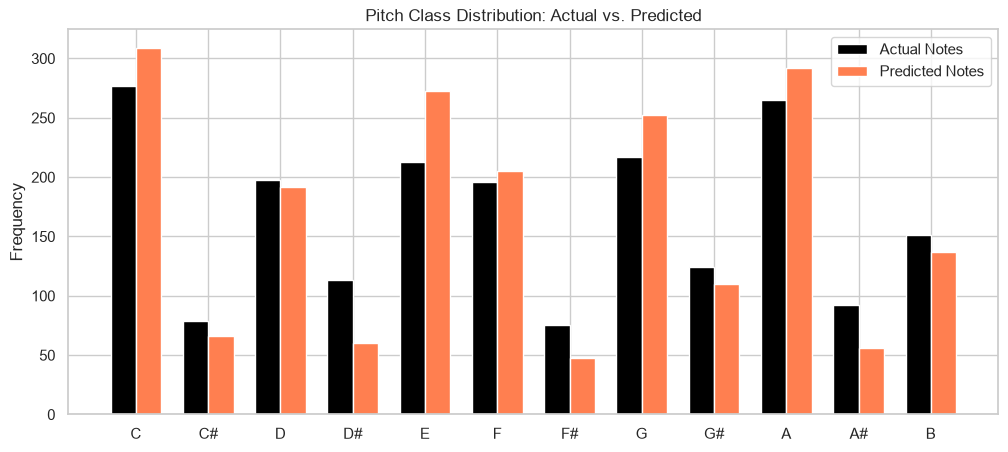


--- Summary Statistics ---
Total sequences evaluated: 2000
Number of unique pitches actually present: 36
Number of unique pitches predicted by model: 36


In [4]:
from sklearn.metrics import confusion_matrix

all_preds = []
all_targets = []

print("Running inference on sampled data...")
with torch.no_grad():
    for batch_x, batch_y in dataloader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        outputs = model(batch_x)
        _, predicted = torch.max(outputs.data, 1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_targets.extend(batch_y.cpu().numpy())

all_preds = np.array(all_preds)
all_targets = np.array(all_targets)

target_pitch_classes = all_targets % 12
pred_pitch_classes = all_preds % 12
pc_names = ['C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B']

plt.figure(figsize=(12, 5))
width = 0.35
x = np.arange(12)

target_counts = [np.sum(target_pitch_classes == i) for i in range(12)]
pred_counts = [np.sum(pred_pitch_classes == i) for i in range(12)]

plt.bar(x - width/2, target_counts, width, label='Actual Notes', color='black')
plt.bar(x + width/2, pred_counts, width, label='Predicted Notes', color='coral')

plt.title("Pitch Class Distribution: Actual vs. Predicted")
plt.xticks(x, pc_names)
plt.ylabel("Frequency")
plt.legend()
plt.show()

unique_targets, counts = np.unique(all_targets, return_counts=True)
top_10_pitches = unique_targets[np.argsort(-counts)][:10]

print("\n--- Summary Statistics ---")
print(f"Total sequences evaluated: {len(all_targets)}")
print(f"Number of unique pitches actually present: {len(np.unique(all_targets))}")
print(f"Number of unique pitches predicted by model: {len(np.unique(all_preds))}")

if len(np.unique(all_preds)) < 5:
    print("\nWARNING: Model might be experiencing mode collapse (predicting very few distinct notes).")